In [31]:
import os
import pandas as pd
import numpy as np


In [32]:
# Load the noASD and ASD dataframes
path = r'D:/Dropbox/Appliedwork/CognitiveSolutions/Projects/DeepEye/TechnicalReports/TechnicalReport1/Test_ASDViewing/noASD/Approved'
path_to_analysis = os.path.join(path, 'analysis')
noASD_social_df = pd.read_csv(os.path.join(path_to_analysis, 'allSubjects_SocialIndex.csv'))
noASD_social_df['Group'] = 'noASD'

path = r'D:/Dropbox/Appliedwork/CognitiveSolutions/Projects/DeepEye/TechnicalReports/TechnicalReport1/Test_ASDViewing/ASD/Approved'
path_to_analysis = os.path.join(path, 'analysis')
ASD_social_df = pd.read_csv(os.path.join(path_to_analysis, 'allSubjects_SocialIndex.csv'))
ASD_social_df['Group'] = 'ASD'

# Combine the two dataframes
social_df = pd.concat([noASD_social_df, ASD_social_df], ignore_index=True)

# Save the combined dataframe to a CSV file
save_path = r'D:/Dropbox/Appliedwork/CognitiveSolutions/Projects/DeepEye/TechnicalReports/TechnicalReport1/Test_ASDViewing'
social_df.to_csv(os.path.join(save_path, 'Groups_SocialIndex.csv'), index=False)


In [33]:
# filter out trials with no fixations on both the social or non-social area, e.g, only fixations on the background
social_df = social_df[
    (social_df['socialIdx_fixCountProp'] > 0) & 
    (social_df['nonsocialIdx_fixCountProp'] > 0)
]

       socialIdx_fixCountProp  socialIdx_fixDurProp  \
Group                                                 
ASD                   0.40243              0.436642   
noASD                 0.41221              0.458822   

       nonsocialIdx_fixCountProp  nonsocialIdx_fixDurProp  total_count  
Group                                                                   
ASD                     0.366972                 0.352373    16.868421  
noASD                   0.381967                 0.391162    21.129032  


<Axes: xlabel='Group'>

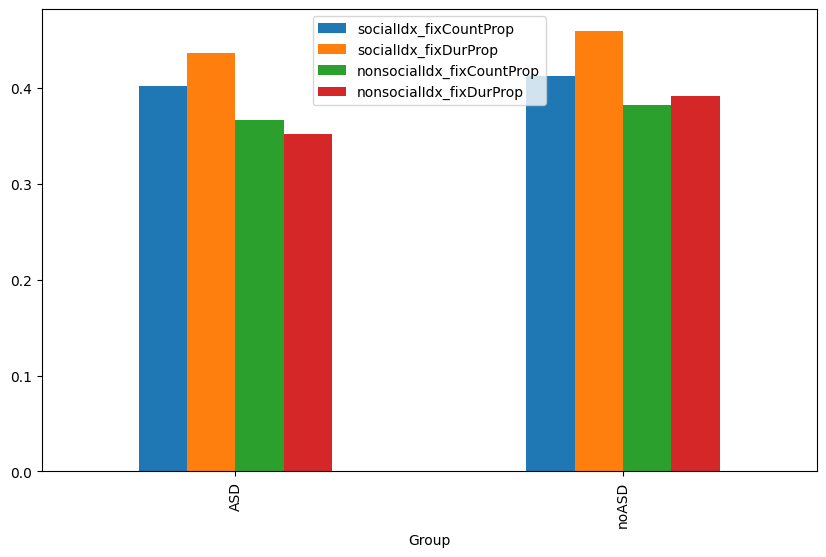

In [ ]:
participant_means = social_df.groupby('deepeye_id').agg({
    'socialIdx_fixCountProp': 'mean',
    'socialIdx_fixDurProp': 'mean',
    'nonsocialIdx_fixCountProp': 'mean',
    'nonsocialIdx_fixDurProp': 'mean',
    # optionally count number of trials per participant
    'pp_id': 'count'  # or any column just to get count
}).rename(columns={'pp_id': 'total_count'})


# Get group info
group_map = social_df[['deepeye_id', 'Group']].drop_duplicates()
participant_means = participant_means.merge(group_map, on='deepeye_id')
participant_means.to_csv(os.path.join(save_path, 'participant_means.csv'), index=False)

# Calculate group averages
group_averages = participant_means.groupby('Group').mean(numeric_only=True)
print(group_averages)

# Plotting the group averages for social and non-social indices
import matplotlib.pyplot as plt
group_averages.drop(columns=['total_count']).plot(kind='bar', figsize=(10, 6))
